## Variational Distribution
We parameterize the following variational distribution:
\begin{equation}
  \label{eq:vardist}
  \begin{split}
    A_{i} \sim \mathrm{Bernoulli}(\alpha_{i}) \\
    \ell_{i} \sim \mathcal N_{T_{i}} (\mu_{i}, \Sigma_{i})
  \end{split}
\end{equation}
where subscript $T_{i}$ means trucation to the tile $T_{i}$.
The variational distribution is $q(\{A_{i}, \ell_{i}\}) = \prod_{i=1}^{T} q(A_{i}, \ell_{i})$.
Unlike in the previous, non-overlapping version, we do not assume that each tile $T_i$ is disjoint.

In this formulation, the variational posterior factorizes over tiles:
$$
q(\{A_i, \ell_i\}) = \prod_{i=1}^T \alpha_i^{A_i} q_i^\ell(\ell_i) ^{A_i} (1 - \alpha_i)^{1 - A_i}.
$$

We want to evaluate the probability of a full, "tile-free" catalog $\{\ell_{n}\}$ under the variational distribution.
However, to do so, we need to know the assignment of each object to a tile $A_n$.

Define $A_{i, n}$ as the indicator of the event that object $n$ was generated by $i$, i.e. $A_{i, n} \triangleq 1[\ell_n = \ell_i]$. Then,
$$
A_n \triangleq \sum_{i=1}^T n A_{i, n}
$$

The number of objects that appear in tile $i$ is a sum. From our variational distribution, this is at most equal to one:
$$
  A_{i} = \sum_{n=1}^{N} A_{i, n}.
$$

The location of the object in tile $i$ can also be expressed as a sum, since at most only one $A_{{i, n}}$ is non-zero:
$$
  \ell_{i} = \sum_{n=1}^{N} A_{i, n} \ell_{n}
$$.

Now, we can re-write the density as follows:
$$
  \begin{split}
    \log q(\{\ell_{n}, A_{n}\}) &= \sum_{i=1}^{T} \log q_{i} (\sum_{n=1}^{N} A_{i, n}, \sum_{n=1}^{N} A_{i, n} \ell_{n}) \\
                                &= \sum_{i=1}^{T} (\sum_{n=1}^{N} A_{i, n}) (\log \alpha_{i} + \log q_{i}^{\ell} (\sum_{n=1}^{N} A_{i, n }\ell_{n})) + (1 - \sum_{n=1}^{N} A_{i, n}) \log (1 - \alpha_{i}) \\
    &= \sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n})\right) + (\frac 1 N - A_{i, n}) \log (1 - \alpha_{i}) \\
                                &= \sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n})\right) - A_{i, n} \log (1 - \alpha_{i}) + \frac 1 N \log (1 - \alpha_{i}) \\
                                &= \sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \\
  \end{split}
$$

Next, we want to integrate out $A_n$.
However, in the case of overlapping tiles, there arises some ambiguity.
If two overlapping tiles detect an object, are there two objects, or just one object counted twice?
To resolve this ambiguity, we add an additional condition that two tiles with overlap cannot be both "on"
$$
A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing
$$
As a result of this assumption, there is at most one object in any tile $T_i$. However, with overlap, it could be the case that $T_i$ did not **generate** that object.

Thus, our variational posterior is:
$$
\tilde q (\{\ell_n, A_n\}) = \frac{q (\{\ell_n, A_n\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing]}{\int q (\{\ell_n, A_n\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing] d \{\ell_n, A_n\}}
$$

where $g(\ell_n)$ is the set of tiles that intersect object $\ell_n$.
The denominator is intractable. The numerator is a lower bound:
$$
q (\{\ell_n, A_n\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing] \le \tilde q (\{\ell_n, A_n\})
$$
As long as the condition $A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing$ is true, $q$ is a lower bound to $\log q$. Since we control the distribution during sleep-phase training, we can guarentee this to be true. One such condition is a **non-overlapping** condition on the locations:
$$
1[\{g(\ell_n) \cap g(\ell_m) = \varnothing\}]
$$
This is stronger than the required condition.

We now integrate out $A_n$ as follows:
$$
\begin{split}
q (\{\ell_n\}) &= \int q (\{\ell_n, A_n\}) d{\{A_n\}} \\
&= \sum_{\{A_n\}} \exp \left (\sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \right )\\
&= \left(\sum_{\{A_n\}} \prod_{n=1}^{N} \frac{\alpha_{A_n}}{1 - \alpha_{A_n}} q_{A_n}^{\ell} (\ell_{n}) \right) \prod_{i=1}^{T} (1 - \alpha_{i})
\end{split}
$$
Note that this distribution is intractable as it requires integrating over all possible combinations of $A_n$. Hence we utilize another lower bound:

$$
\begin{split}
\log q (\{\ell_n\}) &= \log \left(\sum_{\{A_n\}} \prod_{n=1}^{N} \frac{\alpha_{A_n}}{1 - \alpha_{A_n}} q_{A_n}^{\ell} (\ell_{n}) \right) \log \prod_{i=1}^{T} (1 - \alpha_{i}) \\
&= \log \left(\sum_{\{A_n \in g(\ell_n) \}} \prod_{n=1}^{N} \frac{\alpha_{A_n}}{1 - \alpha_{A_n}} q_{A_n}^{\ell} (\ell_{n}) \right) \log \prod_{i=1}^{T} (1 - \alpha_{i}) \\
&\ge \sum_{\{A_n \in g(\ell_n)\}} \left (\sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \right )\\
&= \left (\sum_{n=1}^{N} \sum_{i \in g(\ell_n)}  A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \right )\\
\end{split}
$$

## FAVI objective
$$
\mathbb E_{P(\{\ell_n\}, X)} \log q (\{\ell_n\}) \ge \mathbb E_{P(\{\ell_n\}, X)} \left (\sum_{n=1}^{N} \sum_{i \in g(\ell_n)}  A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \right )
$$
This is a lower bound to the true FAVI objective for two reasons. First, we do not use the normalized $\tilde q$ that "filters" two overlapping tiles being on at the same time. Second, we bring a logarithm inside an expectation for tractability.

\section{Discussion}
In our variational distribution, $\alpha_{i}$ is the probability that an object was generated by tile $i$ given that no other tiles placed an object in the vicinity of tile $i$.

$P(A_i | A_{neighbor(i)} = 0) \propto P(A_i, A_{neighbor(i)} = 0) \propto \alpha_i^{A_i} (1 - \alpha_i)^{1 - A_i} \prod_j (1 - \alpha_j) \propto \alpha_i^{A_i} (1 - \alpha_i)^{1 - A_i}$.

Note that if we consider "odd" tiles, we recover the original disjoint tiles.
Is the optimal distribution for the "odd" tiles the same as for the originals?
i.e. if we use two separate neural networks for odd and even tiles, would the optimum be the same?
Perhaps yes, if we consider a lower bound.
\[
\mathbb E_{P(\{\ell_n\}, X)} \log q (\{\ell_n\})  \ge \mathbb E_{P(\{\ell_n\}, X)} \sum_{n=1}^{N}\sum_{A_n \in g(n)} \log \frac{\alpha_{A_n}}{1 - \alpha_{A_n}} q_{A_n}^{\ell} (\ell_{n})  + \sum_{i=1}^{T} \log (1 - \alpha_{i})
\]

In [1]:
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
from einops import rearrange, repeat
import torch

from case_studies.sdss_galaxies_vae.reconstruction import load_models, reconstruct_scene_at_coordinates

In [2]:
import os
os.environ["BLISS_HOME"] = "/home/dereklh/projects/bliss/"

In [3]:
with initialize(config_path="../sdss_galaxies_vae/config", job_name="overlap"):
    cfg = compose(config_name="config", overrides=["models.prior.mean_sources=0.4"])   
    #print(OmegaConf.to_yaml(cfg))

simulated_dataset = instantiate(cfg.datasets.simulated)

In [4]:
simulated_dataset = instantiate(cfg.datasets.simulated)

In [5]:
batch_size=1
n_tiles_h=5
n_tiles_w=5
#tile_catalog = simulated_dataset.sample_prior(batch_size, n_tiles_h, n_tiles_w)
#torch.save(tile_catalog, "catalog.pt")
tile_catalog = torch.load("catalog.pt")

In [6]:
img, bg = simulated_dataset.simulate_image_from_catalog(tile_catalog)

In [7]:
import matplotlib.pyplot as plt

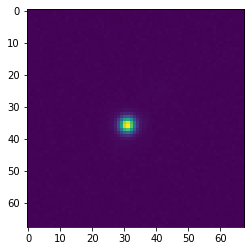

In [8]:
%matplotlib inline
plt.imshow(img[0, 0])

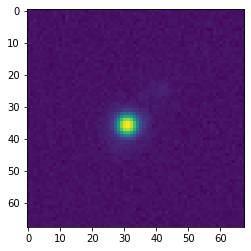

In [9]:

plt.imshow(img[0, 0].log())

In [10]:
tile_catalog["galaxy_params"].shape

torch.Size([1, 5, 5, 1, 7])

In [11]:
# load bliss
device = torch.device(cfg.reconstruct.device)
decoder, encoder, _ = load_models(cfg, device)
bp = 24
h, w = img.shape[2], img.shape[3]
# img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h-bp), (bp, w-bp))
img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 66.22it/s]


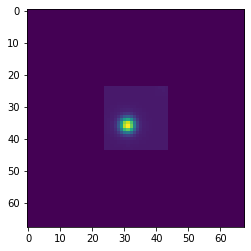

In [12]:
plt.imshow(torch.nn.functional.pad(img_recon[0, 0], (bp, bp, bp, bp)))

In [13]:
tile_map_recon.n_sources

tensor([[[0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0]]], device='cuda:0')

In [14]:
tile_catalog.n_sources

tensor([[[0, 0, 1, 1, 1],
         [1, 0, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 1, 1, 0, 0],
         [1, 0, 0, 1, 0]]])

In [15]:
tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[1.0886e-02, 1.0291e-03, 4.2216e-04, 1.2440e-03, 9.5565e-01],
        [5.4389e-03, 4.2726e-03, 2.0736e-03, 1.0185e-03, 2.7473e-03],
        [4.2320e-03, 7.0130e-02, 1.5814e-02, 3.8231e-03, 3.1865e-04],
        [9.4259e-04, 9.7566e-01, 9.6018e-04, 1.8863e-02, 2.0899e-04],
        [1.5006e-03, 4.6265e-03, 2.6795e-02, 2.5833e-03, 1.1662e-03]],
       device='cuda:0')

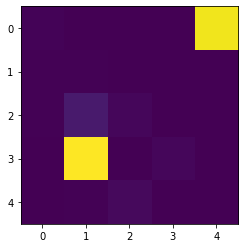

In [16]:
plt.imshow(tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

In [17]:
tile_map_recon.locs[0, 3, 1, 0]

tensor([0.0496, 0.8247], device='cuda:0')

In [18]:
tile_catalog.locs[0, 3, 1, 0]

tensor([0.0322, 0.8106])

In [19]:
tile_catalog2 = tile_catalog.copy()
tile_catalog2.locs = tile_catalog.locs.clone()
tile_catalog2.locs[0, 3, 1, 0] = 0.999

In [20]:
img2, bg2 = simulated_dataset.simulate_image_from_catalog(tile_catalog2)

In [21]:
img_recon2, tile_map_recon2 = reconstruct_scene_at_coordinates(encoder, decoder, img2, bg2, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 73.46it/s]


In [22]:
tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[7.6317e-05, 8.0812e-05, 2.8482e-04, 8.7452e-04, 9.7587e-01],
        [4.7139e-03, 4.0082e-03, 5.6268e-04, 1.3028e-03, 9.0326e-04],
        [4.7289e-03, 3.8422e-03, 3.1773e-03, 3.0032e-03, 1.5888e-03],
        [3.1965e-03, 1.2839e-01, 1.7279e-01, 8.3252e-03, 1.7748e-04],
        [1.3984e-03, 1.6320e-01, 9.6017e-02, 8.3761e-03, 1.0526e-04]],
       device='cuda:0')

In [23]:
tile_map_recon2["n_source_log_probs"][0, 3:5, 1:3, 0, 0].exp().sum()

tensor(0.5604, device='cuda:0')

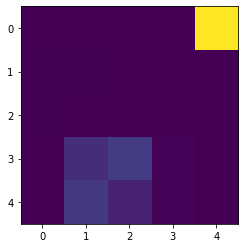

In [24]:
plt.imshow(tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

## Overlapping test

In [25]:
img2.shape

torch.Size([1, 1, 68, 68])

In [26]:
img2_shifted = torch.zeros_like(img2)
img2_shifted[:, :, :-2, :-2] += img2[:, :, 2:, 2:]
img2_shifted[:, :, -2:, -2:] = bg2[:, :, -2:, -2:]

bg2_shifted = torch.zeros_like(bg2)
bg2_shifted[:, :, :-2, :-2] += bg2[:, :, 2:, 2:]
bg2_shifted[:, :, -2:, -2:] = bg2[:, :, -2:, -2:]

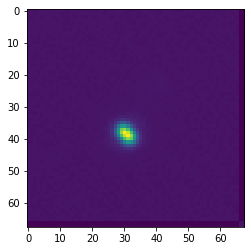

In [27]:
plt.imshow(img2_shifted[0, 0] + img2[0, 0])

In [28]:
img_recon2_shifted, tile_map_recon2_shifted = reconstruct_scene_at_coordinates(encoder, decoder, img2_shifted, bg2_shifted, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 62.15it/s]


In [29]:
tile_map_recon2_shifted["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[8.5364e-04, 1.6717e-03, 1.0769e-02, 1.1055e-02, 7.6055e-03],
        [1.8516e-03, 9.6875e-04, 1.9499e-03, 1.0884e-03, 5.2506e-04],
        [2.2028e-03, 5.1457e-03, 7.7478e-03, 1.9092e-03, 1.1513e-03],
        [1.4494e-03, 9.9962e-01, 1.8778e-04, 3.8112e-03, 2.7532e-04],
        [7.7649e-04, 1.1540e-04, 2.7878e-03, 4.0994e-04, 1.2290e-04]],
       device='cuda:0')

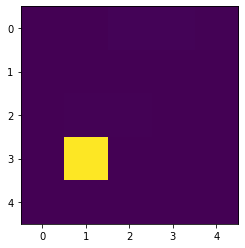

In [30]:
plt.imshow(tile_map_recon2_shifted["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

Okay, so how does our MCMC algorithm work?
1. Start with all tiles at zero
1. Sample original first
1. Sample overlap given original
1. Sample original given overlap
1. etc

In [31]:
log_probs = torch.stack((
    tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0],
    tile_map_recon2_shifted["n_source_log_probs"][0, :, :, 0, 0],
), dim = -1)

In [32]:
log_probs.shape

torch.Size([5, 5, 2])

In [33]:
def has_neighbor(idx, tiles):
    other = 1 - idx
    if idx == 0: #original; overlap is to the bottom and right
        neighbors_0 = (1 - tiles[:, :, other]) # has neighbor to bottom-right
        neighbors_0[1:, :]  *= (1 - tiles[:-1, :, other]) # has neighbor to top-right
        neighbors_0[:, 1:]  *= (1 - tiles[:, :-1, other]) # has neighbor to bottom-left
        neighbors_0[1:, 1:] *= (1 - tiles[:-1, :-1, other]) # has beighbor to top-left
    if idx == 1: #overlap; original is to the top and left
        neighbors_0 = (1 - tiles[:, :, other]) # has neighbor to top-left
        neighbors_0[:-1, :]  *= (1 - tiles[1:, :, other]) # has neighbor to bottom-right
        neighbors_0[:, :-1]  *= (1 - tiles[:, 1:, other]) # has neighbor to top-right
        neighbors_0[:-1, :-1] *= (1 - tiles[1:, 1:, other]) # has beighbor to bottom-right
    return neighbors_0

In [34]:
def sample_tile_marginals(log_probs, n_samples=1000):
    tiles = torch.zeros_like(log_probs, dtype=int)
    sum_tiles = torch.zeros_like(log_probs)
    for _ in range(n_samples):
        for idx in (0, 1):
            neighbors_0 = has_neighbor(idx, tiles)
            #print(neighbors_0)
            tiles[:, :, idx] = (torch.rand_like(tiles[:, :, 0], dtype=float).log() < log_probs[:, :, idx]) * neighbors_0
            #print(tiles[:, :, idx])
        sum_tiles += tiles
    return sum_tiles / n_samples

In [35]:
def calc_tile_marginals(log_probs, n_iter=200):
    tiles = torch.ones_like(log_probs) * 0.5
    for _ in range(n_iter):
        for idx in (0, 1):
            neighbors_0 = has_neighbor(idx, tiles)
            #print(neighbors_0)
            tiles[:, :, idx] = (log_probs[:, :, idx] + neighbors_0.log()).exp()
            #print(tiles[:, :, idx])
    return tiles

In [36]:
x = sample_tile_marginals(log_probs)

In [37]:
y = calc_tile_marginals(log_probs)

In [38]:
x[:, :, 0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.9810],
        [0.0030, 0.0050, 0.0000, 0.0010, 0.0000],
        [0.0070, 0.0080, 0.0040, 0.0060, 0.0010],
        [0.0060, 0.0000, 0.0020, 0.0060, 0.0000],
        [0.0010, 0.0010, 0.0000, 0.0070, 0.0000]], device='cuda:0')

In [39]:
x[:, :, 1]

tensor([[0.0010, 0.0000, 0.0190, 0.0000, 0.0000],
        [0.0010, 0.0000, 0.0010, 0.0030, 0.0000],
        [0.0020, 0.0120, 0.0070, 0.0010, 0.0000],
        [0.0010, 0.9980, 0.0000, 0.0020, 0.0000],
        [0.0000, 0.0000, 0.0030, 0.0000, 0.0000]], device='cuda:0')

In [40]:
y[:, :, 0]

tensor([[7.6252e-05, 8.0609e-05, 2.8129e-04, 8.6489e-04, 9.7543e-01],
        [4.7013e-03, 3.9871e-03, 5.5411e-04, 1.2846e-03, 9.0140e-04],
        [4.7100e-03, 3.8037e-03, 3.1278e-03, 2.9657e-03, 1.5814e-03],
        [3.1850e-03, 1.0836e-04, 1.4523e-04, 8.2136e-03, 1.7623e-04],
        [1.3953e-03, 1.3863e-04, 8.1504e-05, 8.3167e-03, 1.0478e-04]],
       device='cuda:0')

In [41]:
y[:, :, 1]

tensor([[8.4611e-04, 1.6636e-03, 1.0737e-02, 2.7086e-04, 1.8673e-04],
        [1.8200e-03, 9.5768e-04, 1.9345e-03, 1.0811e-03, 5.2376e-04],
        [2.1769e-03, 5.1088e-03, 7.6363e-03, 1.8846e-03, 1.1493e-03],
        [1.4424e-03, 9.9915e-01, 1.8465e-04, 3.7474e-03, 2.7524e-04],
        [7.7530e-04, 1.1538e-04, 2.7644e-03, 4.0649e-04, 1.2289e-04]],
       device='cuda:0')

In [42]:
x.sum()

tensor(2.0900, device='cuda:0')

In [43]:
y.sum()

tensor(2.0732, device='cuda:0')

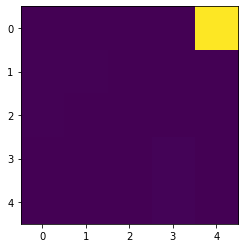

In [44]:
plt.imshow(y[:,:, 0].cpu())

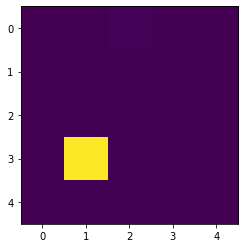

In [45]:
plt.imshow(y[:,:,1].cpu())

In [46]:
x=y

In [47]:
x_dbl = repeat(x, "h w d -> (h h2) (w w2) d",h2=2, w2=2).cpu()
x_super = torch.zeros(x_dbl.shape[0] + 1, x_dbl.shape[1] + 1)

In [48]:
x_super[:-1, :-1] += x_dbl[:, :, 0]
x_super[1:, 1:] += x_dbl[:, :, 1]

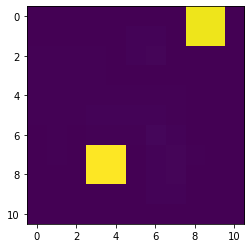

In [49]:
plt.imshow(x_super)

In [50]:
x_super.max()

tensor(0.9993)

## More complicated method


In [56]:
log_probs = torch.stack((
    tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0],
    tile_map_recon2_shifted["n_source_log_probs"][0, :, :, 0, 0],
), dim = 0)

loc_means = torch.stack((
    tile_map_recon2["loc_mean"][0, :, :, 0, :],
    tile_map_recon2_shifted["loc_mean"][0, :, :, 0, :],
), dim = 0)

loc_sds = torch.stack((
    tile_map_recon2["loc_sd"][0, :, :, 0, :],
    tile_map_recon2_shifted["loc_sd"][0, :, :, 0, :],
), dim = 0)


In [57]:
loc_means.shape

torch.Size([2, 5, 5, 2])

In [ ]:
# Get probability of each subtile

In [97]:
loc_means_h = loc_means[:, :, :, 0]
loc_means_w = loc_means[:, :, :, 1]
loc_sds_h = loc_sds[:, :, :, 0]
loc_sds_w = loc_sds[:, :, :, 1]

In [104]:
dist_h = torch.distributions.Normal(loc_means_h, loc_sds_h)
dist_w = torch.distributions.Normal(loc_means_w, loc_sds_w)

In [101]:
device = loc_means_h.device
start = torch.tensor(0.0, device = device)
mid = torch.tensor(0.5, device = device)
end = torch.tensor(1.0, device = device)

In [102]:
prob_h_top = (dist_h.cdf(mid) - dist_h.cdf(start)) / (dist_h.cdf(end) - dist_h.cdf(start)) 

In [112]:
prob_h_top.shape

torch.Size([2, 5, 5])

In [103]:
prob_h_top

tensor([[[2.4066e-01, 3.3330e-01, 2.7583e-01, 6.4948e-01, 9.9978e-01],
         [9.4466e-02, 2.1323e-01, 3.3355e-01, 6.7344e-01, 7.5048e-01],
         [6.1240e-01, 4.7821e-01, 4.1708e-01, 5.3416e-01, 4.5880e-01],
         [4.2817e-01, 4.0922e-05, 1.4465e-03, 4.0777e-01, 4.7818e-01],
         [5.7378e-01, 1.0000e+00, 1.0000e+00, 6.6945e-01, 5.3568e-01]],

        [[2.8298e-01, 2.3284e-01, 6.2150e-01, 9.2023e-01, 9.5213e-01],
         [3.4334e-01, 5.6661e-01, 5.5225e-01, 4.8148e-01, 4.2109e-01],
         [4.4280e-01, 2.8778e-01, 4.0182e-01, 4.9530e-01, 4.9816e-01],
         [4.8575e-01, 3.5684e-01, 5.4693e-01, 5.1474e-01, 3.8377e-01],
         [6.7888e-01, 7.2866e-01, 6.3896e-01, 7.3948e-01, 6.5476e-01]]],
       device='cuda:0')

In [116]:
prob_h_bot = 1 - prob_h_top
prob_h = torch.stack((prob_h_top, prob_h_bot), dim=-1)
prob_h = rearrange(prob_h, "nl nth ntw sh -> nl nth ntw sh 1", sh=2)

In [117]:
prob_w_left = (dist_w.cdf(mid) - dist_w.cdf(start)) / (dist_w.cdf(end) - dist_w.cdf(start)) 

In [118]:
prob_w_left

tensor([[[5.4175e-01, 6.7931e-01, 4.6247e-01, 2.5716e-01, 2.5988e-01],
         [2.9079e-01, 6.8431e-01, 3.7332e-01, 4.3056e-01, 5.1944e-01],
         [5.0725e-01, 4.5969e-01, 4.3755e-01, 5.1833e-01, 5.7558e-01],
         [3.6801e-01, 2.3055e-04, 9.8812e-01, 6.0567e-01, 7.2405e-01],
         [3.7693e-01, 0.0000e+00, 1.0000e+00, 6.1770e-01, 7.4118e-01]],

        [[5.0771e-01, 5.5072e-01, 3.0110e-01, 1.2579e-01, 9.1081e-01],
         [6.6918e-01, 4.0307e-01, 4.8522e-01, 4.6648e-01, 7.1591e-01],
         [4.2528e-01, 4.2946e-01, 5.6844e-01, 5.7361e-01, 5.0681e-01],
         [2.7691e-01, 7.8428e-01, 6.5153e-01, 5.9915e-01, 7.0212e-01],
         [3.2590e-01, 4.2465e-01, 5.1040e-01, 6.5698e-01, 4.7951e-01]]],
       device='cuda:0')

In [119]:
prob_w_right = 1 - prob_w_left
prob_w = torch.stack((prob_w_left, prob_w_right), dim=-1)
prob_w = rearrange(prob_w, "nl nth ntw sw -> nl nth ntw 1 sw", sw=2)

torch.Size([2, 5, 5])

In [120]:
probs_in_tile = prob_h * prob_w

In [121]:
probs_in_tile.shape

torch.Size([2, 5, 5, 2, 2])

In [124]:
probs_in_tile[0, 3, 3]

tensor([[0.2470, 0.1608],
        [0.3587, 0.2335]], device='cuda:0')

In [127]:
log_probs.shape

torch.Size([2, 5, 5])

In [126]:
def sample_subtile_marginals(log_probs, probs_in_tile, n_samples=1000):
    tiles = torch.zeros_like(log_probs, dtype=bool)
    subtiles = torch.zeros_like(probs_in_tile, dtype=bool)
    log_subtile_probs = 
    for _ in range(n_samples):
        for idx in (0, 1):
            for h in (0, 1):
                for w in (0, 1):
                    no_neighbors = has_no_neighbor_subtile(subtiles, idx, h, w)
                    is_on = (torch.rand_like(subtiles[idx, :, :, h, w], dtype=float).log() < log_subtile_probs[idx, :, :, h, w]) * no_neighbors
                    subtiles[idx, :, :, h, w] = is_on
        sum_tiles += tiles
    return sum_tiles / n_samples